In [1]:
import numpy

import AILibs 

dt = 1.0/1000.0 
    

a = numpy.zeros((2, 2))
b = numpy.zeros((2, 1))

a[0][1] = 1
a[1][1] = -4

b[1][0] = 5.0

c = numpy.zeros((1, 2))
c[0][0] = 1
 
ds = AILibs.DynamicalSystem(a, b, c, dt)

print(ds)



mat_a = 
0.0 1.0 
0.0 -4.0 


mat_b = 
0.0 
5.0 


mat_c = 
1.0 0.0 





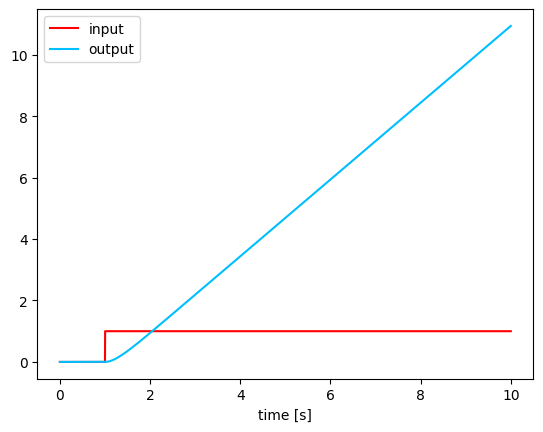

In [2]:
n_steps = 10000

t_result = []
u_result = []
x_result = []

ds.reset()
u = 1
for n in range(n_steps):

    u_tmp = numpy.ones((1, 1))

    if n > n_steps//10:
        u = 1.0
    else:
        u = 0.0

    x, y = ds.forward_state(u_tmp*u)

    t_result.append(n*dt)
    u_result.append(u) 
    x_result.append(x[0][0])


t_result = numpy.array(t_result)
u_result = numpy.array(u_result)
x_result = numpy.array(x_result)


import matplotlib.pyplot as plt

plt.plot(t_result, u_result, label="input", color="red")
plt.plot(t_result, x_result, label="output", color="deepskyblue")
plt.xlabel("time [s]")
plt.legend()
plt.show()


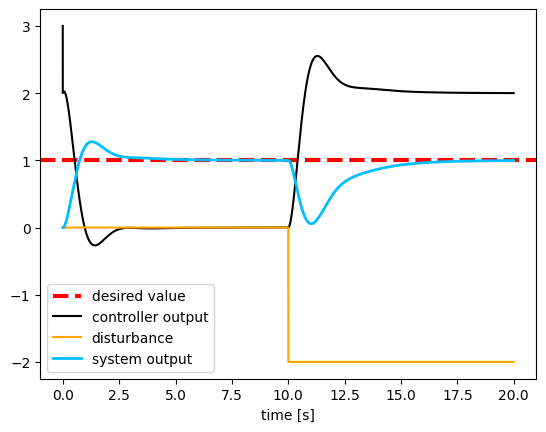

In [3]:
kp = 2 
ki = 0.001
kd = 1.0


pid = AILibs.PID(kp, ki, kd)

n_steps = 20000


xr = 1.0
x  = 0.0
u  = 0.0


t_result    = []
u_result    = []
d_result    = []
xr_result   = []
x_result    = []

ds.reset()  
pid.reset()

for n in range(n_steps):

    
    u = pid.forward(xr, x, u)

    u_tmp = numpy.ones((1, 1))

    if n > n_steps//2:
        d = -2
    else:
        d = 0

    x, y = ds.forward_state(u_tmp*(u + d))

    x = x[0][0]

    t_result.append(n*dt)
    u_result.append(u) 
    d_result.append(d) 
    xr_result.append(xr)
    x_result.append(x)


t_result    = numpy.array(t_result)
u_result    = numpy.array(u_result)
d_result    = numpy.array(d_result)
xr_result   = numpy.array(xr_result)
x_result    = numpy.array(x_result)


import matplotlib.pyplot as plt

plt.axhline(y=xr, color='red', linestyle='--', label='desired value', lw=3)
plt.plot(t_result, u_result, label="controller output", color="black")
plt.plot(t_result, d_result, label="disturbance", color="orange")
plt.plot(t_result, x_result, label="system output", color="deepskyblue", lw=2)
plt.xlabel("time [s]")
plt.legend()
plt.show()


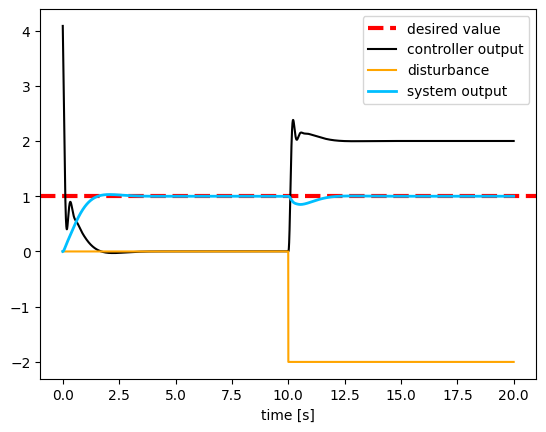

In [4]:


b0 = 3.0
wc = 3.5
wo = 4*wc

adrc = AILibs.LinearADRC2ndOrder(b0, wc, wo, dt)

n_steps = 20000 


xr = 1.0
x  = 0.0    
u  = 0.0


t_result    = []
u_result    = []
d_result    = []
xr_result   = []
x_result    = []

ds.reset()  
adrc.reset()    

for n in range(n_steps):

    
    u = adrc.forward(xr, x, u)

    u_tmp = numpy.ones((1, 1))

    if n > n_steps//2:
        d = -2
    else:
        d = 0

    x, y = ds.forward_state(u_tmp*(u + d))

    x = x[0][0]

    t_result.append(n*dt)
    u_result.append(u) 
    d_result.append(d) 
    xr_result.append(xr)
    x_result.append(x)


t_result    = numpy.array(t_result)
u_result    = numpy.array(u_result)
d_result    = numpy.array(d_result)
xr_result   = numpy.array(xr_result)
x_result    = numpy.array(x_result)


import matplotlib.pyplot as plt

plt.axhline(y=xr, color='red', linestyle='--', label='desired value', lw=3)
plt.plot(t_result, u_result, label="controller output", color="black")
plt.plot(t_result, d_result, label="disturbance", color="orange")
plt.plot(t_result, x_result, label="system output", color="deepskyblue", lw=2)
plt.xlabel("time [s]")
plt.legend()
plt.show()  
